## Exponentials & Logarithms — Visualizing the Derivatives

Two new functions this day, each with a special derivative that doesn't come
from the power rule:

- **$e^x$ is its own derivative:** $\frac{d}{dx}e^x = e^x$. The slope of the
  curve at any point equals its height there — no other function does this. It's
  why $e$ is called "natural": for a general base, $\frac{d}{dx}a^x = a^x \ln a$,
  and only $a = e$ makes the extra factor $\ln a = 1$ disappear.
- **$\ln x$ has derivative $\frac{1}{x}$:** $\frac{d}{dx}\ln x = \frac{1}{x}$.

### What the plots below show

- **Left — $e^x$ vs its derivative:** we plot $e^x$ and its derivative on the
  same axes. They land *exactly on top of each other*, because they are the same
  function. This is the visual proof that the slope of $e^x$ at any $x$ equals
  $e^x$ itself.
- **Right — $\ln x$ vs $\frac{1}{x}$:** $\ln x$ climbs slowly, while its
  derivative $\frac{1}{x}$ starts high near zero and falls off. This matches the
  picture: the slope of $\ln x$ is steep for small $x$ and flattens as $x$ grows.

These two derivatives are the backbone of functions used later — $e^x$ inside the
sigmoid and softmax, $\ln x$ inside cross-entropy — and of log-returns in quant.

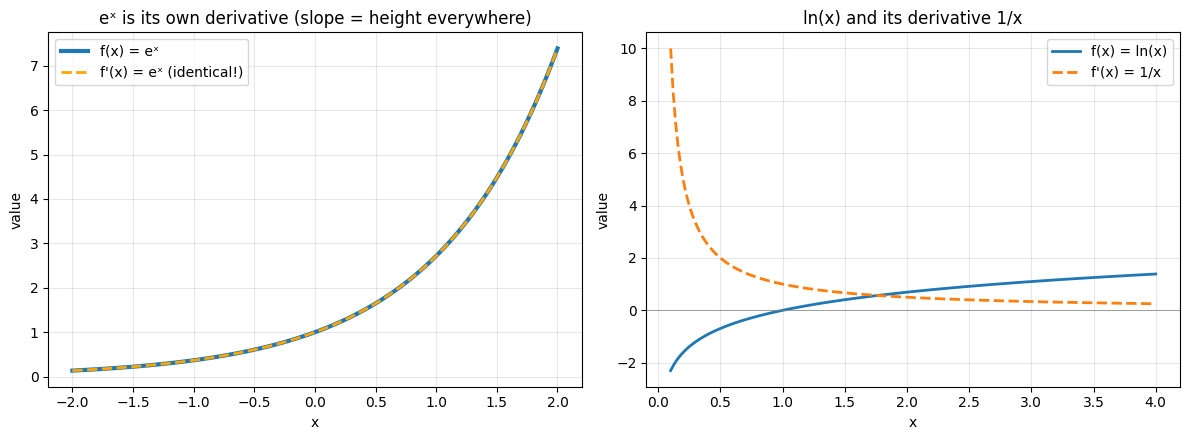

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# --- e^x and its derivative (which is also e^x) ---
x1 = np.linspace(-2, 2, 200)
ax1.plot(x1, np.exp(x1), label="f(x) = eˣ", lw=3)
ax1.plot(x1, np.exp(x1), "--", color="orange", label="f'(x) = eˣ (identical!)", lw=2)
ax1.set_title("eˣ is its own derivative (slope = height everywhere)")
ax1.set_xlabel("x"); ax1.set_ylabel("value")
ax1.legend(); ax1.grid(True, alpha=0.3)

# --- ln(x) and its derivative 1/x ---
x2 = np.linspace(0.1, 4, 200)          # ln only defined for x > 0
ax2.plot(x2, np.log(x2), label="f(x) = ln(x)", lw=2)
ax2.plot(x2, 1/x2, "--", label="f'(x) = 1/x", lw=2)
ax2.axhline(0, color="gray", lw=0.5)
ax2.set_title("ln(x) and its derivative 1/x")
ax2.set_xlabel("x"); ax2.set_ylabel("value")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##  Application of the concept Part(1/3): Continuous compounding uses eˣ

Recall today's intuition: $e^x$ models growth whose *rate is proportional to the
current amount*. Money is exactly that — interest earns on what you already have.

If you compound **continuously** (every instant, not yearly or monthly), an amount
$P$ growing at rate $r$ for time $t$ becomes:

$$A = P \cdot e^{rt}$$

That $e^{rt}$ is today's exponential doing real work. The reason it's $e$ (and not
some other base) is precisely the Step 1 fact: continuous, proportional growth
*is* the definition of $e$. So "continuously compounded" and "$e^{rt}$" are the
same statement.

##  Application Part(2/3): The log-return is ln run backward (and a derivative in disguise)

Section 1 went forward: money grows by $e^{rt}$. Here we run it backward with $\ln$
(the inverse of $e^x$) to measure how much a price *did* grow.

A price goes from $P_0$ to $P_1$. The **simple return** is the fractional change:

$$R_{\text{simple}} = \frac{P_1 - P_0}{P_0}$$

Quants usually use the **log-return** instead:

$$r_{\text{log}} = \ln\!\left(\frac{P_1}{P_0}\right)$$

**Why ln?** From Section 1, continuous growth means $P_1 = P_0 e^{r}$. Solving for
$r$ undoes the $e$ with a $\ln$:

$$r = \ln\!\left(\frac{P_1}{P_0}\right)$$

So the log-return *is* the continuously-compounded rate that turned $P_0$ into $P_1$.

**A derivative in disguise:** using $\ln\frac{a}{b} = \ln a - \ln b$,

$$r_{\text{log}} = \ln P_1 - \ln P_0$$

— a **difference of log-prices**. A difference across a time step is what a
derivative approximates, so the log-return is the discrete form of the derivative
of log-price.

## Application Part(3/3): Why quants prefer log-returns — they add across time

The practical payoff. For a price path $P_0 \to P_1 \to P_2$, the daily log-returns
**sum** to the whole-period log-return:

$$\ln\frac{P_1}{P_0} + \ln\frac{P_2}{P_1} = \ln\frac{P_2}{P_0}$$

**Why:** the price ratios multiply ($\frac{P_1}{P_0}\cdot\frac{P_2}{P_1} = \frac{P_2}{P_0}$),
and today's log rule $\ln a + \ln b = \ln(ab)$ turns that multiplication into
addition.

**Why it matters:** simple returns don't add — you'd multiply $(1+R_1)(1+R_2)\cdots$.
Log-returns let you *sum* across time, average, and annualize cleanly, which makes
every downstream statistic (mean, volatility, Sharpe) simpler. This is why
log-returns are the standard preprocessing step in quant.

In [36]:

prices = np.array([100.0, 102.0, 101.0, 105.0])




# # log returns:  ln(P1/P0) = ln(P1) - ln(P0)
log_ret = np.diff(np.log(prices))          # np.diff = difference of consecutive log-prices
print("log returns:   ", np.round(log_ret, 5))

# # the key property: daily log-returns ADD to the whole-period log-return
total_log = np.log(prices[-1] / prices[0])
print("\nsum of daily log returns:", round(log_ret.sum(), 5))
print("total log return 100->105:", round(total_log, 5))
print("sum of dailuy log returns matched with total log return ?", np.isclose(log_ret.sum(), total_log))


# Simple calcualtion for price change
daily_simple = prices[1:] / prices[:-1] - 1
total_simple = prices[-1] / prices[0] -1

print("\ntotal simple ", total_simple)
print("sum of daily simple returns", daily_simple.sum())
print("sum of daily simple returns matched with total simple return ?", np.isclose(total_simple, daily_simple.sum()))


log returns:    [ 0.0198  -0.00985  0.03884]

sum of daily log returns: 0.04879
total log return 100->105: 0.04879
sum of dailuy log returns matched with total log return ? True

total simple  0.050000000000000044
sum of daily simple returns 0.04980003882741224
sum of daily simple returns matched with total simple return ? False


## Self-check — Day 4 (Exponentials, Logarithms & their Derivatives)

Answer each out loud before opening the answers.

**Q1.** What is $\frac{d}{dx}e^x$, and what makes this property unique to $e$?

**Q2.** What is $\frac{d}{dx}\ln x$?

**Q3.** Differentiate (chain rule): (a) $e^{5x}$  (b) $\ln(x^3 + 2x)$.

**Q4.** Why does $\frac{d}{dx}\ln(3x) = \frac{1}{x}$ — the same as $\ln(x)$ —
even though there's a 3 inside?

**Q5.** In $A = P\,e^{rt}$, what does each of $A, P, r, t$ mean, and why is the
base $e$ (rather than some other number)?

**Q6.** Write the log-return between prices $P_0$ and $P_1$ two equivalent ways,
and explain why it's called "a derivative in disguise."

**Q7.** Why do quants prefer log-returns over simple returns? Name the key
property and why simple returns only *approximately* share it for small moves.

---

<details>
<summary>Answers</summary>

**A1.** $\frac{d}{dx}e^x = e^x$ — it is its own derivative (slope equals height
everywhere). Unique to $e$ because for a general base $\frac{d}{dx}a^x = a^x\ln a$,
and only $a=e$ makes the factor $\ln a = \ln e = 1$, leaving no extra constant.

**A2.** $\frac{d}{dx}\ln x = \frac{1}{x}$.

**A3.** (a) copy $e^{5x}$, times inner derivative $5$ → $5e^{5x}$.
(b) $\frac{u'}{u} = \frac{3x^2+2}{x^3+2x}$.

**A4.** Because $\ln(3x) = \ln 3 + \ln x$; $\ln 3$ is a constant (derivative 0),
leaving $\frac{d}{dx}\ln x = \frac{1}{x}$. Any constant multiplier inside a log
vanishes on differentiation.

**A5.** $A$ = end amount, $P$ = starting principal, $r$ = growth rate per unit
time (decimal), $t$ = time. The base is $e$ because continuous, proportional
growth is exactly what $e^x$ describes — "continuously compounded" *means* $e^{rt}$.

**A6.** $r_{\log} = \ln\!\left(\frac{P_1}{P_0}\right) = \ln P_1 - \ln P_0$. It's a
*difference of log-prices*, and a difference across a time step is what a
derivative approximates — so it's the discrete form of the derivative of log-price.

**A7.** Log-returns **add across time** (daily log-returns sum to the period
log-return), because price ratios multiply and $\ln$ turns multiplication into
addition. Simple returns truly *multiply* $(1+R_1)(1+R_2)$; they only look
additive for small returns because $\ln(1+R)\approx R$ when $R$ is small.

</details>